# YOLOv9 Fine-Tuning Guide
This notebook will guide you through the process of fine-tuning YOLOv9 for object detection tasks. We'll cover:

Setting up the YOLOv9 environment.
Preparing and verifying the dataset.
Fine-tuning the YOLOv9 model.
Validating and visualizing the results.


### 1. Prepare the Dataset
This section covers how to prepare your dataset for YOLOV9

This script takes a single flat folder containing YOLO-labeled images and their .txt annotation files, then splits them into train, val, and test sets. It creates a YOLOv9-compatible folder structure with subdirectories for images/ and labels/, ensuring each image and its matching label file are kept together.

In [5]:
import os
import shutil
import random
from pathlib import Path

def split_flat_yolo_folder(flat_dir, output_dir, train_ratio=0.8, val_ratio=0.1, test_ratio=0.1):
    """
    Splits a flat folder containing YOLO images and labels into train/val/test folders.
    
    :param flat_dir: Path to the flat directory containing both .jpg/.png and .txt files.
    :param output_dir: Path to output dataset directory with /images and /labels.
    :param train_ratio: Proportion of data for training.
    :param val_ratio: Proportion of data for validation.
    :param test_ratio: Proportion of data for testing.
    """
    assert round(train_ratio + val_ratio + test_ratio, 5) == 1.0, "Ratios must sum to 1"

    flat_dir = Path(flat_dir)
    output_dir = Path(output_dir)

    # Prepare output folder structure
    for split in ['train', 'val', 'test']:
        (output_dir / 'images' / split).mkdir(parents=True, exist_ok=True)
        (output_dir / 'labels' / split).mkdir(parents=True, exist_ok=True)

    # Collect all image files
    image_files = [f for f in flat_dir.iterdir() if f.suffix.lower() in ['.jpg', '.jpeg', '.png']]
    random.shuffle(image_files)

    # Split indices
    total = len(image_files)
    train_end = int(train_ratio * total)
    val_end = train_end + int(val_ratio * total)

    splits = {
        'train': image_files[:train_end],
        'val': image_files[train_end:val_end],
        'test': image_files[val_end:]
    }

    # Move images and their corresponding labels
    for split, files in splits.items():
        for img_file in files:
            label_file = flat_dir / f"{img_file.stem}.txt"
            shutil.copy2(img_file, output_dir / 'images' / split / img_file.name)
            if label_file.exists():
                shutil.copy2(label_file, output_dir / 'labels' / split / label_file.name)

    print(f"✅ Dataset split complete: {len(splits['train'])} train, {len(splits['val'])} val, {len(splits['test'])} test")

# Example usage
cwd = os.getcwd()
flat_source = f"{cwd}/Blackbouys"
output_dataset = f"{cwd}/BB_Addon"

split_flat_yolo_folder(flat_source, output_dataset, train_ratio=0.8, val_ratio=0.1, test_ratio=0.1)

✅ Dataset split complete: 105 train, 13 val, 14 test


This cleanup script ensures the integrity of the YOLOv9 dataset by removing any invalid or incomplete data. Specifically, it scans through the `train`, `val`, and `test` folders and deletes label files that are empty, along with their corresponding images. It also removes any image that does not have a matching `.txt` annotation file. This step is essential before training, as unlabeled or improperly labeled images can negatively impact model performance and cause training errors.


In [2]:
import os

def delete_empty_labels_and_images(dataset_dir):
    """
    Deletes images and labels where the label file is empty or missing.

    :param dataset_dir: The root dataset directory containing 'images' and 'labels' folders.
    """
    images_dir = os.path.join(dataset_dir, "images")
    labels_dir = os.path.join(dataset_dir, "labels")

    # Supported image extensions
    image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".tiff")

    # Process train, val, test folders
    for split in ["train", "val", "test"]:
        split_images_dir = os.path.join(images_dir, split)
        split_labels_dir = os.path.join(labels_dir, split)

        # Ensure directories exist
        if not os.path.exists(split_images_dir) or not os.path.exists(split_labels_dir):
            continue

        # Iterate over label files
        for label_file in os.listdir(split_labels_dir):
            if label_file.endswith(".txt"):
                label_path = os.path.join(split_labels_dir, label_file)
                image_path = os.path.join(split_images_dir, os.path.splitext(label_file)[0] + ".jpg")  # Change if different format

                # Check if label file is empty
                if os.path.getsize(label_path) == 0:
                    os.remove(label_path)  # Delete label file
                    if os.path.exists(image_path):
                        os.remove(image_path)  # Delete corresponding image
                        print(f"Deleted empty label file and image: {label_file}, {image_path}")

        # Iterate over images to check for missing label files
        for image_file in os.listdir(split_images_dir):
            if image_file.lower().endswith(image_extensions):
                image_path = os.path.join(split_images_dir, image_file)
                label_path = os.path.join(split_labels_dir, os.path.splitext(image_file)[0] + ".txt")

                # If the image has no corresponding label file, delete it
                if not os.path.exists(label_path):
                    os.remove(image_path)
                    print(f"Deleted image without label: {image_file}")

# Example Usage
cwd = os.getcwd()
dataset_root = f"{cwd}/BB_Addon"
delete_empty_labels_and_images(dataset_root)


This script performs data augmentation on a YOLO-formatted dataset by applying transformations such as flips, rotations, brightness adjustments, noise, and blur to images in the train, val, and test folders. It preserves the original YOLO bounding box format by updating and saving corresponding label files for each augmented image. The original images and labels are also copied to the output directory, and a specified number of augmented versions are generated per image, making it easier to expand the dataset and improve model robustness during training.

In [3]:
import os
import cv2
import numpy as np
import albumentations as A
from tqdm import tqdm

def augment_images(dataset_dir, output_dir, num_augmentations=3):
    """
    Applies data augmentation to images in 'train', 'val', and 'test' subfolders
    while preserving the YOLO label structure.

    :param dataset_dir: Path to dataset containing 'images/train', 'images/val', 'images/test' folders.
    :param output_dir: Path to save augmented images and labels.
    :param num_augmentations: Number of augmented images to generate per original image.
    """

    splits = ["train", "val", "test"]
    
    for split in splits:
        images_dir = os.path.join(dataset_dir, "images", split)
        labels_dir = os.path.join(dataset_dir, "labels", split)

        output_images_dir = os.path.join(output_dir, "images", split)
        output_labels_dir = os.path.join(output_dir, "labels", split)

        os.makedirs(output_images_dir, exist_ok=True)
        os.makedirs(output_labels_dir, exist_ok=True)

        if not os.path.exists(images_dir) or not os.path.exists(labels_dir):
            print(f"Skipping {split}: Directory does not exist")
            continue

        # Image augmentation pipeline
        transform = A.Compose([
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.3),
            A.RandomBrightnessContrast(p=0.5),
            A.GaussianBlur(blur_limit=3, p=0.2),
            A.Rotate(limit=20, p=0.5),
            A.ISONoise(p=0.3),
        ], bbox_params=A.BboxParams(format='yolo', label_fields=['category']))

        image_files = [f for f in os.listdir(images_dir) if f.endswith((".jpg", ".png", ".jpeg"))]

        for image_file in tqdm(image_files, desc=f"Augmenting {split} images"):
            image_path = os.path.join(images_dir, image_file)
            label_path = os.path.join(labels_dir, os.path.splitext(image_file)[0] + ".txt")

            # Load image
            image = cv2.imread(image_path)
            height, width = image.shape[:2]

            # Load YOLO label (if exists)
            if os.path.exists(label_path):
                with open(label_path, "r") as f:
                    lines = f.readlines()
                
                # Parse bounding boxes in YOLO format
                bboxes = []
                categories = []
                for line in lines:
                    parts = line.strip().split()
                    class_id = int(parts[0])
                    x_center, y_center, w, h = map(float, parts[1:])
                    bboxes.append([x_center, y_center, w, h])
                    categories.append(class_id)
            else:
                bboxes = []
                categories = []

            # Save original image & label
            cv2.imwrite(os.path.join(output_images_dir, image_file), image)
            if os.path.exists(label_path):
                with open(os.path.join(output_labels_dir, os.path.basename(label_path)), "w") as f:
                    f.writelines(lines)

            # Generate augmented images
            for i in range(num_augmentations):
                augmented = transform(image=image, bboxes=bboxes, category=categories)

                # Save augmented image
                aug_filename = f"{os.path.splitext(image_file)[0]}_aug{i}.jpg"
                cv2.imwrite(os.path.join(output_images_dir, aug_filename), augmented["image"])

                # Save corresponding label file
                if bboxes:
                    label_filename = f"{os.path.splitext(image_file)[0]}_aug{i}.txt"
                    with open(os.path.join(output_labels_dir, label_filename), "w") as f:
                        for bbox, category in zip(augmented["bboxes"], categories):
                            f.write(f"{category} {' '.join(map(str, bbox))}\n")

    print("Data augmentation completed!")

# Example Usage
dataset_root = f"{cwd}/BB_Addon"
output_root = f"{cwd}/BB_Augmented"  # Change this to your output dataset path
augment_images(dataset_root, output_root, num_augmentations=3)


Augmenting test images: 100%|██████████| 14/14 [00:27<00:00,  1.95s/it]

Data augmentation completed!


### 2. Combine datasets
This section covers how to combine two datasets

This script allows you to flexibly remap class IDs in YOLO annotation files across the train, val, and test splits of your dataset. By passing a custom dictionary of label mappings (e.g., {0: 4, 1: 5, ..., 12: 16}), you can adjust class indices to match a unified label scheme across multiple datasets. It reads each .txt label file, replaces class IDs according to the mapping, and overwrites the file with the updated labels. This is especially useful when merging datasets with different label conventions or when you want to reindex classes for consistency before training.

In [ ]:
import os

def remap_labels(labels_dir, mapping):
    """
    Remaps YOLO class IDs in label files based on a user-defined mapping.

    :param labels_dir: Root 'labels/' directory containing 'train', 'val', 'test' subfolders.
    :param mapping: Dictionary mapping old class IDs to new class IDs (e.g., {8: 23, 10: 22}).
    """
    for split in ["train", "val", "test"]:
        split_labels_dir = os.path.join(labels_dir, split)
        if not os.path.exists(split_labels_dir):
            print(f"Skipping {split}: Directory does not exist.")
            continue

        txt_files = [f for f in os.listdir(split_labels_dir) if f.endswith(".txt")]

        for txt_file in txt_files:
            file_path = os.path.join(split_labels_dir, txt_file)

            with open(file_path, "r") as f:
                lines = f.readlines()

            modified_lines = []
            for line in lines:
                parts = line.strip().split()
                if not parts:
                    continue

                try:
                    class_id = int(parts[0])
                    if class_id in mapping:
                        parts[0] = str(mapping[class_id])  # Apply remapping
                    modified_lines.append(" ".join(parts))
                except ValueError:
                    print(f"⚠️ Skipping invalid line in {txt_file}: {line.strip()}")
                    modified_lines.append(line.strip())  # Retain invalid line

            with open(file_path, "w") as f:
                f.write("\n".join(modified_lines) + "\n")

            print(f"✅ Remapped labels in: {txt_file}")


def verify_remapped_labels(labels_dir):
    """
    Displays unique class IDs for train/val/test to verify the remapping.

    :param labels_dir: Root 'labels/' directory.
    """
    for split in ["train", "val", "test"]:
        split_dir = os.path.join(labels_dir, split)
        if not os.path.exists(split_dir):
            print(f"Skipping {split}: Directory does not exist.")
            continue

        unique_ids = set()
        for txt_file in os.listdir(split_dir):
            if txt_file.endswith(".txt"):
                with open(os.path.join(split_dir, txt_file), "r") as f:
                    for line in f:
                        parts = line.strip().split()
                        if parts and parts[0].isdigit():
                            unique_ids.add(int(parts[0]))

        print(f"✅ {split.upper()} contains class IDs: {sorted(unique_ids)}")


def check_for_unexpected_labels(labels_dir, expected_ids):
    """
    Scans YOLO label files and identifies unexpected class IDs,
    printing the exact files and lines where they occur.
    
    :param labels_dir: Root labels directory (must contain train/val/test)
    :param expected_ids: Set of valid/expected class IDs (e.g., {0,1,2})
    """
    splits = ["train", "val", "test"]
    for split in splits:
        split_path = os.path.join(labels_dir, split)
        if not os.path.exists(split_path):
            print(f"❌ {split.upper()} directory not found.")
            continue

        unexpected_ids = set()
        print(f"\n🔍 Checking {split.upper()}...")
        for file in os.listdir(split_path):
            if not file.endswith(".txt"):
                continue
            file_path = os.path.join(split_path, file)
            with open(file_path, "r") as f:
                lines = f.readlines()

            for idx, line in enumerate(lines):
                parts = line.strip().split()
                if not parts:
                    continue
                try:
                    class_id = int(parts[0])
                    if class_id not in expected_ids:
                        print(f"⚠️  Unexpected class ID {class_id} in {file} (line {idx + 1})")
                        unexpected_ids.add(class_id)
                except ValueError:
                    print(f"❗ Skipping malformed line in {file}: {line.strip()}")

        if unexpected_ids:
            print(f"\n⚠️ {split.upper()} has unexpected class IDs: {sorted(unexpected_ids)}")
        else:
            print(f"✅ {split.upper()} contains only expected class IDs.")

def check_dataset_labels(labels_dir, expected_ids):
    """
    Checks label files for:
    - Unexpected class IDs (outside expected_ids)
    - Missing class IDs (expected but never used)

    :param labels_dir: Directory containing 'train', 'val', and 'test' subfolders with .txt labels
    :param expected_ids: Set of expected class IDs (e.g., set(range(6,16)))
    """
    splits = ["train", "val", "test"]
    used_class_ids = set()

    for split in splits:
        split_path = os.path.join(labels_dir, split)
        if not os.path.exists(split_path):
            print(f"❌ {split.upper()} directory not found.")
            continue

        unexpected_ids = set()
        print(f"\n🔍 Checking {split.upper()}...")
        for file in os.listdir(split_path):
            if not file.endswith(".txt"):
                continue
            file_path = os.path.join(split_path, file)
            with open(file_path, "r") as f:
                lines = f.readlines()

            for idx, line in enumerate(lines):
                parts = line.strip().split()
                if not parts:
                    continue
                try:
                    class_id = int(parts[0])
                    used_class_ids.add(class_id)
                    if class_id not in expected_ids:
                        print(f"⚠️  Unexpected class ID {class_id} in {file} (line {idx + 1})")
                        unexpected_ids.add(class_id)
                except ValueError:
                    print(f"❗ Malformed line in {file}: {line.strip()}")

        if unexpected_ids:
            print(f"⚠️ {split.upper()} has unexpected class IDs: {sorted(unexpected_ids)}")
        else:
            print(f"✅ {split.upper()} contains only expected class IDs.")

    # After all splits: check if any expected ID was never used
    missing_ids = expected_ids - used_class_ids
    if missing_ids:
        print(f"\n⚠️ Expected class IDs not found in any split: {sorted(missing_ids)}")
    else:
        print("\n✅ All expected class IDs were found in the dataset.")

# === Example usage ===

# Example usage:
cwd = os.getcwd()
check_dataset_labels(
    f"{cwd}/ScanDockDeliver.v2i.yolov9/labels",
    set(range(0, 11))  # Expected remapped classes
)
# Remap 0–12 to 4–16
remap_labels(
    f"{cwd}/ScanDockDeliver.v2i.yolov9/labels",
    {old: new for old, new in zip(range(0, 11), range(6, 17))}
)

check_dataset_labels(
    f"{cwd}/dataset_augmentations/labels", {
    17
})
remap_labels(f"{cwd}/rb25_dataset_augmented/labels", {
    0: 17
})

# ✅ Check what labels are in each split
verify_remapped_labels(f"{cwd}/rb25_dataset_augmented/labels")

# 🚨 Check for unexpected class IDs outside 4–16
check_for_unexpected_labels(f"{cwd}/rb25_dataset_augmented/labels", {17})

check_for_unexpected_labels(f"{cwd}/ScanDockDeliver.v2i.yolov9/labels", set(range(6, 17)))



🔍 Checking TRAIN...
⚠️  Unexpected class ID 14 in 20231025012647_jpg.rf.0e0df39117e7b8fc4da3368e0d368db2.txt (line 1)
⚠️  Unexpected class ID 11 in 20231025012647_jpg.rf.0e0df39117e7b8fc4da3368e0d368db2.txt (line 2)
⚠️  Unexpected class ID 12 in 20231025012647_jpg.rf.0e0df39117e7b8fc4da3368e0d368db2.txt (line 6)
⚠️  Unexpected class ID 14 in 20231025012647_jpg.rf.33149c219db908a37cc9f18497117dea.txt (line 1)
⚠️  Unexpected class ID 11 in 20231025012647_jpg.rf.33149c219db908a37cc9f18497117dea.txt (line 2)
⚠️  Unexpected class ID 12 in 20231025012647_jpg.rf.33149c219db908a37cc9f18497117dea.txt (line 6)
⚠️  Unexpected class ID 14 in 20231025012647_jpg.rf.aedd045e09bdbec6b9c4e56c1236b8df.txt (line 1)
⚠️  Unexpected class ID 11 in 20231025012647_jpg.rf.aedd045e09bdbec6b9c4e56c1236b8df.txt (line 2)
⚠️  Unexpected class ID 12 in 20231025012647_jpg.rf.aedd045e09bdbec6b9c4e56c1236b8df.txt (line 6)
⚠️  Unexpected class ID 14 in 20231025012650_jpg.rf.94e92b8c91e9597c588431439457ef9f.txt (line 1)

This script enables the merging of multiple YOLOv9 datasets into a single, unified dataset structure. It processes the images and labels from the train, val, and test subdirectories of each dataset and copies them into corresponding folders in the target merged directory. To prevent overwriting files with the same name, it automatically appends the dataset folder name as a prefix when conflicts are detected. This modular approach allows seamless integration of multiple datasets (2, 3, or more) and is ideal for consolidating data from different sources before training a unified model.

In [2]:
import os
import shutil

def merge_datasets(datasets, merged_dir):
    splits = ['train', 'val', 'test']
    types = ['images', 'labels']

    # Create merged directory structure
    for typ in types:
        for split in splits:
            os.makedirs(os.path.join(merged_dir, typ, split), exist_ok=True)

    for dataset in datasets:
        for typ in types:
            for split in splits:
                src_dir = os.path.join(dataset, typ, split)
                dst_dir = os.path.join(merged_dir, typ, split)

                if not os.path.exists(src_dir):
                    print(f"Warning: {src_dir} does not exist. Skipping...")
                    continue

                for filename in os.listdir(src_dir):
                    src_file = os.path.join(src_dir, filename)
                    dst_file = os.path.join(dst_dir, filename)

                    # Handle filename conflicts by appending a prefix
                    if os.path.exists(dst_file):
                        name, ext = os.path.splitext(filename)
                        filename = f"{os.path.basename(dataset)}_{name}{ext}"
                        dst_file = os.path.join(dst_dir, filename)

                    shutil.copy2(src_file, dst_file)

    print(f"✅ Merged datasets into {merged_dir}")
cwd = os.getcwd()
# === USAGE ===
dataset1 = f"{cwd}/ScanDockDeliver.v2i.yolov9"
dataset2 = f"{cwd}/VRX_Perception.v4i.yolov9"
dataset3 = f"{cwd}/dataset_augmentations"
merged_output = f"{cwd}/combined_vrx_dataset"

merge_datasets([dataset1, dataset2, dataset3], merged_output)


✅ Merged datasets into e:\NEMOTRAIN\YoloV9 Training Tutorial\AI_Training/combined_vrx_dataset


### 3. Create Data Yaml
Creating the data.yaml file

This script generates a YOLOv9-compatible data.yaml file by allowing the user to specify the training and validation image directories, as well as a custom list of class names. It automatically sets the number of classes (nc) based on the length of the class list and formats the YAML content accordingly. This modular approach ensures consistency and flexibility when preparing datasets for training, especially when working with multiple datasets or dynamically defined class sets. The output file is ready to be used directly with YOLOv9’s train.py script.

In [5]:
import yaml
import os

def create_data_yaml(save_path, train_dir, val_dir, class_names):
    """
    Generates a YOLOv9-compatible data.yaml file.

    :param save_path: Where to save the data.yaml file.
    :param train_dir: Path to images/train directory.
    :param val_dir: Path to images/val directory.
    :param class_names: A list of class names (e.g., ['buoy', 'dock', 'boat']).
    """
    data = {
        'train': train_dir,
        'val': val_dir,
        'nc': len(class_names),
        'names': class_names
    }

    # Ensure the output directory exists
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    with open(save_path, 'w') as f:
        yaml.dump(data, f, default_flow_style=False)

    print(f"✅ data.yaml created at: {save_path}")
cwd = os.getcwd()
# === EXAMPLE USAGE ===
output_yaml_path = f"{cwd}/BB_Augmented/data.yaml"
train_images_path = f"{cwd}\\BB_Augmented\\images\\train"
val_images_path   = f"{cwd}\\BB_Augmented\\images\\val"
class_list = [
    'black_buoy',
    'green_buoy',
    'red_buoy',
    'white_buoy',
    'black_ball',
    'orange_ball',
    'black_light',
    'blue_light',
    'circle',
    'cross',
    'docking_bay',
    'green_light',
    'rectangle',
    'red_light',
    'light_buoy',
    'triangle',
    'yellow_light',
    'wamv'
]


create_data_yaml(output_yaml_path, train_images_path, val_images_path, class_list)


✅ data.yaml created at: /media/amore/Vision_AGX1_EXT4/Vision_AGX1/NEMOTRAIN/YoloV9 Training Tutorial/AI_Training/BB_Augmented/data.yaml


#### 4. Train Dataset

Parameters Explained:

*  **batch**: Batch size for training.
*  **epochs**: Number of training epochs
*  **img:** Input image size.
*  **device**: GPU device ID (use cpu if GPU is not available).
*  **data**: Path to the data configuration file.
*  **weights**: Path to the pre-trained weights.
*  **cfg**: Model configuration file.
*  **hyp**: Hyperparameter configuration file.

In [4]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"


In [36]:
!python3 /home/xavi/AI_Training/yolov9/train.py \
--batch 8 \
--epochs 15 \
--img 640 \
--device 0 \
--data /home/xavi/AI_Training/vrx_dataset/data.yaml \
--weights /home/xavi/AI_Training/yolov9/weights/gelan-c.pt \
--cfg /home/xavi/AI_Training/yolov9/models/detect/gelan-c.yaml \
--hyp /home/xavi/AI_Training/yolov9/data/hyps/hyp.scratch-high.yaml 



2025-07-11 00:39:29.222795: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-11 00:39:29.322113: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-11 00:39:29.362720: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-11 00:39:29.376132: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-11 00:39:29.450915: I tensorflow/core/platform/cpu_feature_guar

#### 5. Validation
This step evaluates the model's performance on a separate validation set after training.

In [38]:
!python3 /home/xavi/AI_Training/yolov9/val.py \
--img 640 \
--batch 32 \
--conf 0.001 \
--iou 0.7 \
--device 0 \
--data /home/xavi/AI_Training/roboboat2024/RoboBoat2025_v3_Dataset/data.yaml \
--weights /home/xavi/AI_Training/yolov9/runs/train/exp25/weights/best.pt

val: data=/home/xavi/AI_Training/roboboat2024/RoboBoat2025_v3_Dataset/data.yaml, weights=['/home/xavi/AI_Training/yolov9/runs/train/exp25/weights/best.pt'], batch_size=32, imgsz=640, conf_thres=0.001, iou_thres=0.7, max_det=300, task=val, device=0, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=yolov9/runs/val, name=exp, exist_ok=False, half=False, dnn=False, min_items=0
YOLOv5 🚀 1e33dbb Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 7943MiB)

/home/xavi/AI_Training/yolov9/models/experimental.py:75: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the defau

#### Re-training (Optional)
If the validation results are satisfactory, you can combine the training and validation sets into a single dataset to re-train the model for deployment. This approach leverages all available labeled data to improve final performance.

In [ ]:
!python3 train.py \
--batch 16 \
--epochs 50 \
--img 640 \
--device 0 \
--data /content/yolov9/roboflow_dataset_combined.yaml \
--weights runs/train/exp/weights/best.pt \
--cfg models/detect/gelan-c.yaml \
--hyp hyp.scratch-high.yaml

### 6. Inference
Perform inference on test images to visually inspect the model’s predictions.

In [39]:
!python3 /home/xavi/AI_Training/yolov9/detect.py \
--img 1280 \
--conf 0.1 \
--device 0 \
--weights /home/xavi/AI_Training/yolov9/runs/train/exp25/weights/best.pt \
--source /home/xavi/AI_Training/roboboat2024/RoboBoat2025_v3_Dataset/images/test

detect: weights=['/home/xavi/AI_Training/yolov9/runs/train/exp25/weights/best.pt'], source=/home/xavi/AI_Training/roboboat2024/RoboBoat2025_v3_Dataset/images/test, data=yolov9/data/coco128.yaml, imgsz=[1280, 1280], conf_thres=0.1, iou_thres=0.45, max_det=1000, device=0, view_img=False, save_txt=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=yolov9/runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 1e33dbb Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 7943MiB)

/home/xavi/AI_Training/yolov9/models/experimental.py:75: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://git

### 7. Visualize Results
Display a few test images with predictions to confirm the model's qualitative performance.

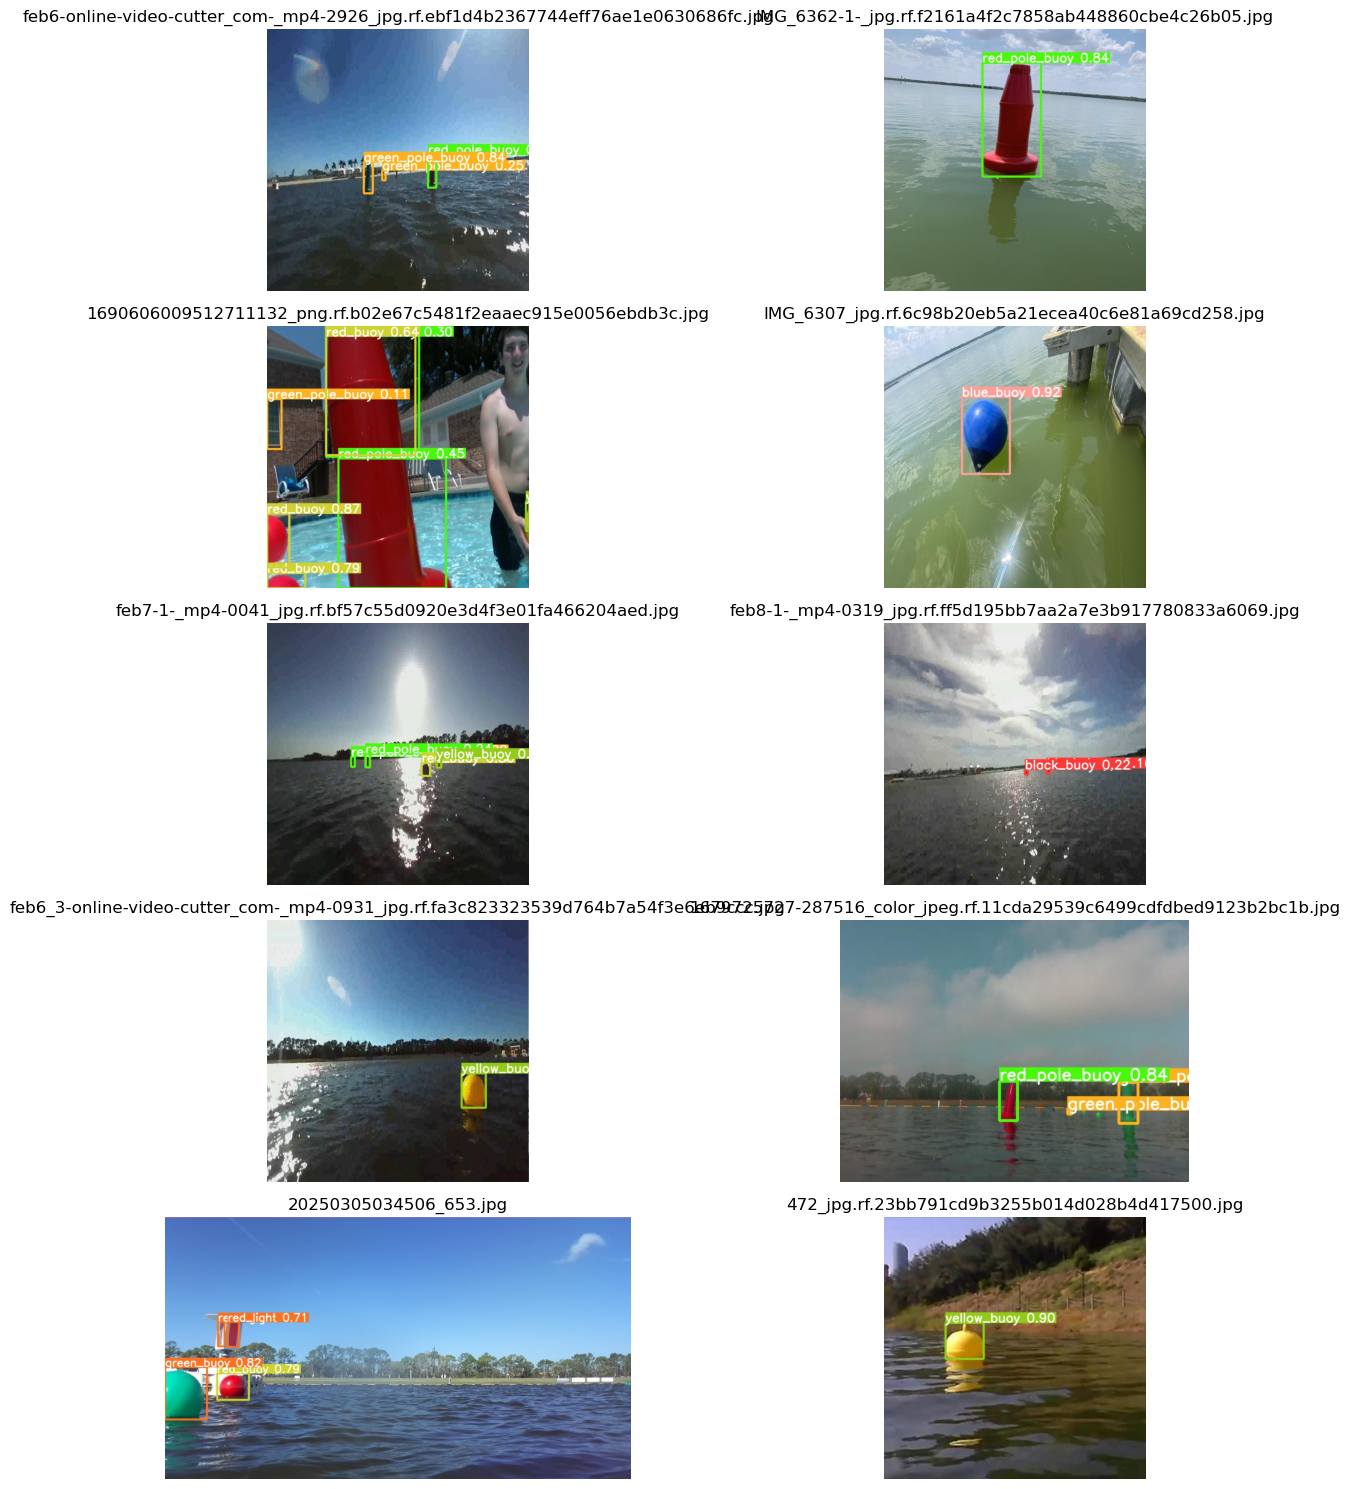

In [64]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Directory where inference images are stored
result_dir = '/home/xavi/AI_Training/yolov9/runs/detect/exp5'

# List all image files in the directory
image_files = [f for f in os.listdir(result_dir) if f.endswith('.jpg') or f.endswith('.png')]

# Randomly select 10 images
selected_images = random.sample(image_files, min(10, len(image_files)))

# Plot the selected images
plt.figure(figsize=(15, 15))
for i, img_name in enumerate(selected_images):
    img_path = os.path.join(result_dir, img_name)
    img = mpimg.imread(img_path)
    plt.subplot(5, 2, i + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(img_name)

plt.tight_layout()
plt.show()

### 10. Save Your Model and Dataset
After completing the training, save the best model weights and the dataset to your Google Drive for future use. This step ensures you can reuse your fine-tuned model and data without retraining.

In [ ]:
import os
import shutil

def export_yolov9_results(exp_folder='exp', dest_dir='/home/xavi/AI_Training/yolov9_export', dataset_folder='roboflow_dataset_combined'):
    """
    Copies best.pt weights and dataset to a specified local directory.

    :param exp_folder: Folder name under yolov9/runs/train (e.g., 'exp', 'exp2', 'exp15').
    :param dest_dir: Output directory to save best.pt and dataset.
    :param dataset_folder: Dataset folder located in /home/xavi/AI_Training/yolov9/
    """
    yolov9_base = "/home/xavi/AI_Training/yolov9"
    weights_path = os.path.join(yolov9_base, "runs", "train", exp_folder, "weights", "best.pt")
    dataset_path = os.path.join(yolov9_base, dataset_folder)

    os.makedirs(dest_dir, exist_ok=True)

    # Copy best.pt
    if os.path.isfile(weights_path):
        shutil.copy2(weights_path, os.path.join(dest_dir, "best.pt"))
        print(f"✅ Copied best.pt from {exp_folder} to {dest_dir}")
    else:
        print(f"❌ Error: best.pt not found in {weights_path}")

    # Optionally copy dataset
    if os.path.isdir(dataset_path):
        dst_dataset = os.path.join(dest_dir, "dataset")
        if not os.path.exists(dst_dataset):
            shutil.copytree(dataset_path, dst_dataset)
            print(f"✅ Dataset copied to {dst_dataset}")
        else:
            print(f"⚠️ Dataset already exists at {dst_dataset}, skipping.")
    else:
        print(f"❌ Dataset folder not found: {dataset_path}")

# === Example Usage ===
export_yolov9_results(
    exp_folder="exp15",  # Update to your actual exp folder
    dest_dir="/home/xavi/AI_Training/yolov9_export",
    dataset_folder="roboflow_dataset_combined"  # Update if using a different dataset
)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cp: cannot stat '/content/yolov9/roboflow_dataset': No such file or directory
Best weights and dataset copied to /content/drive/MyDrive/yolov9_project/
